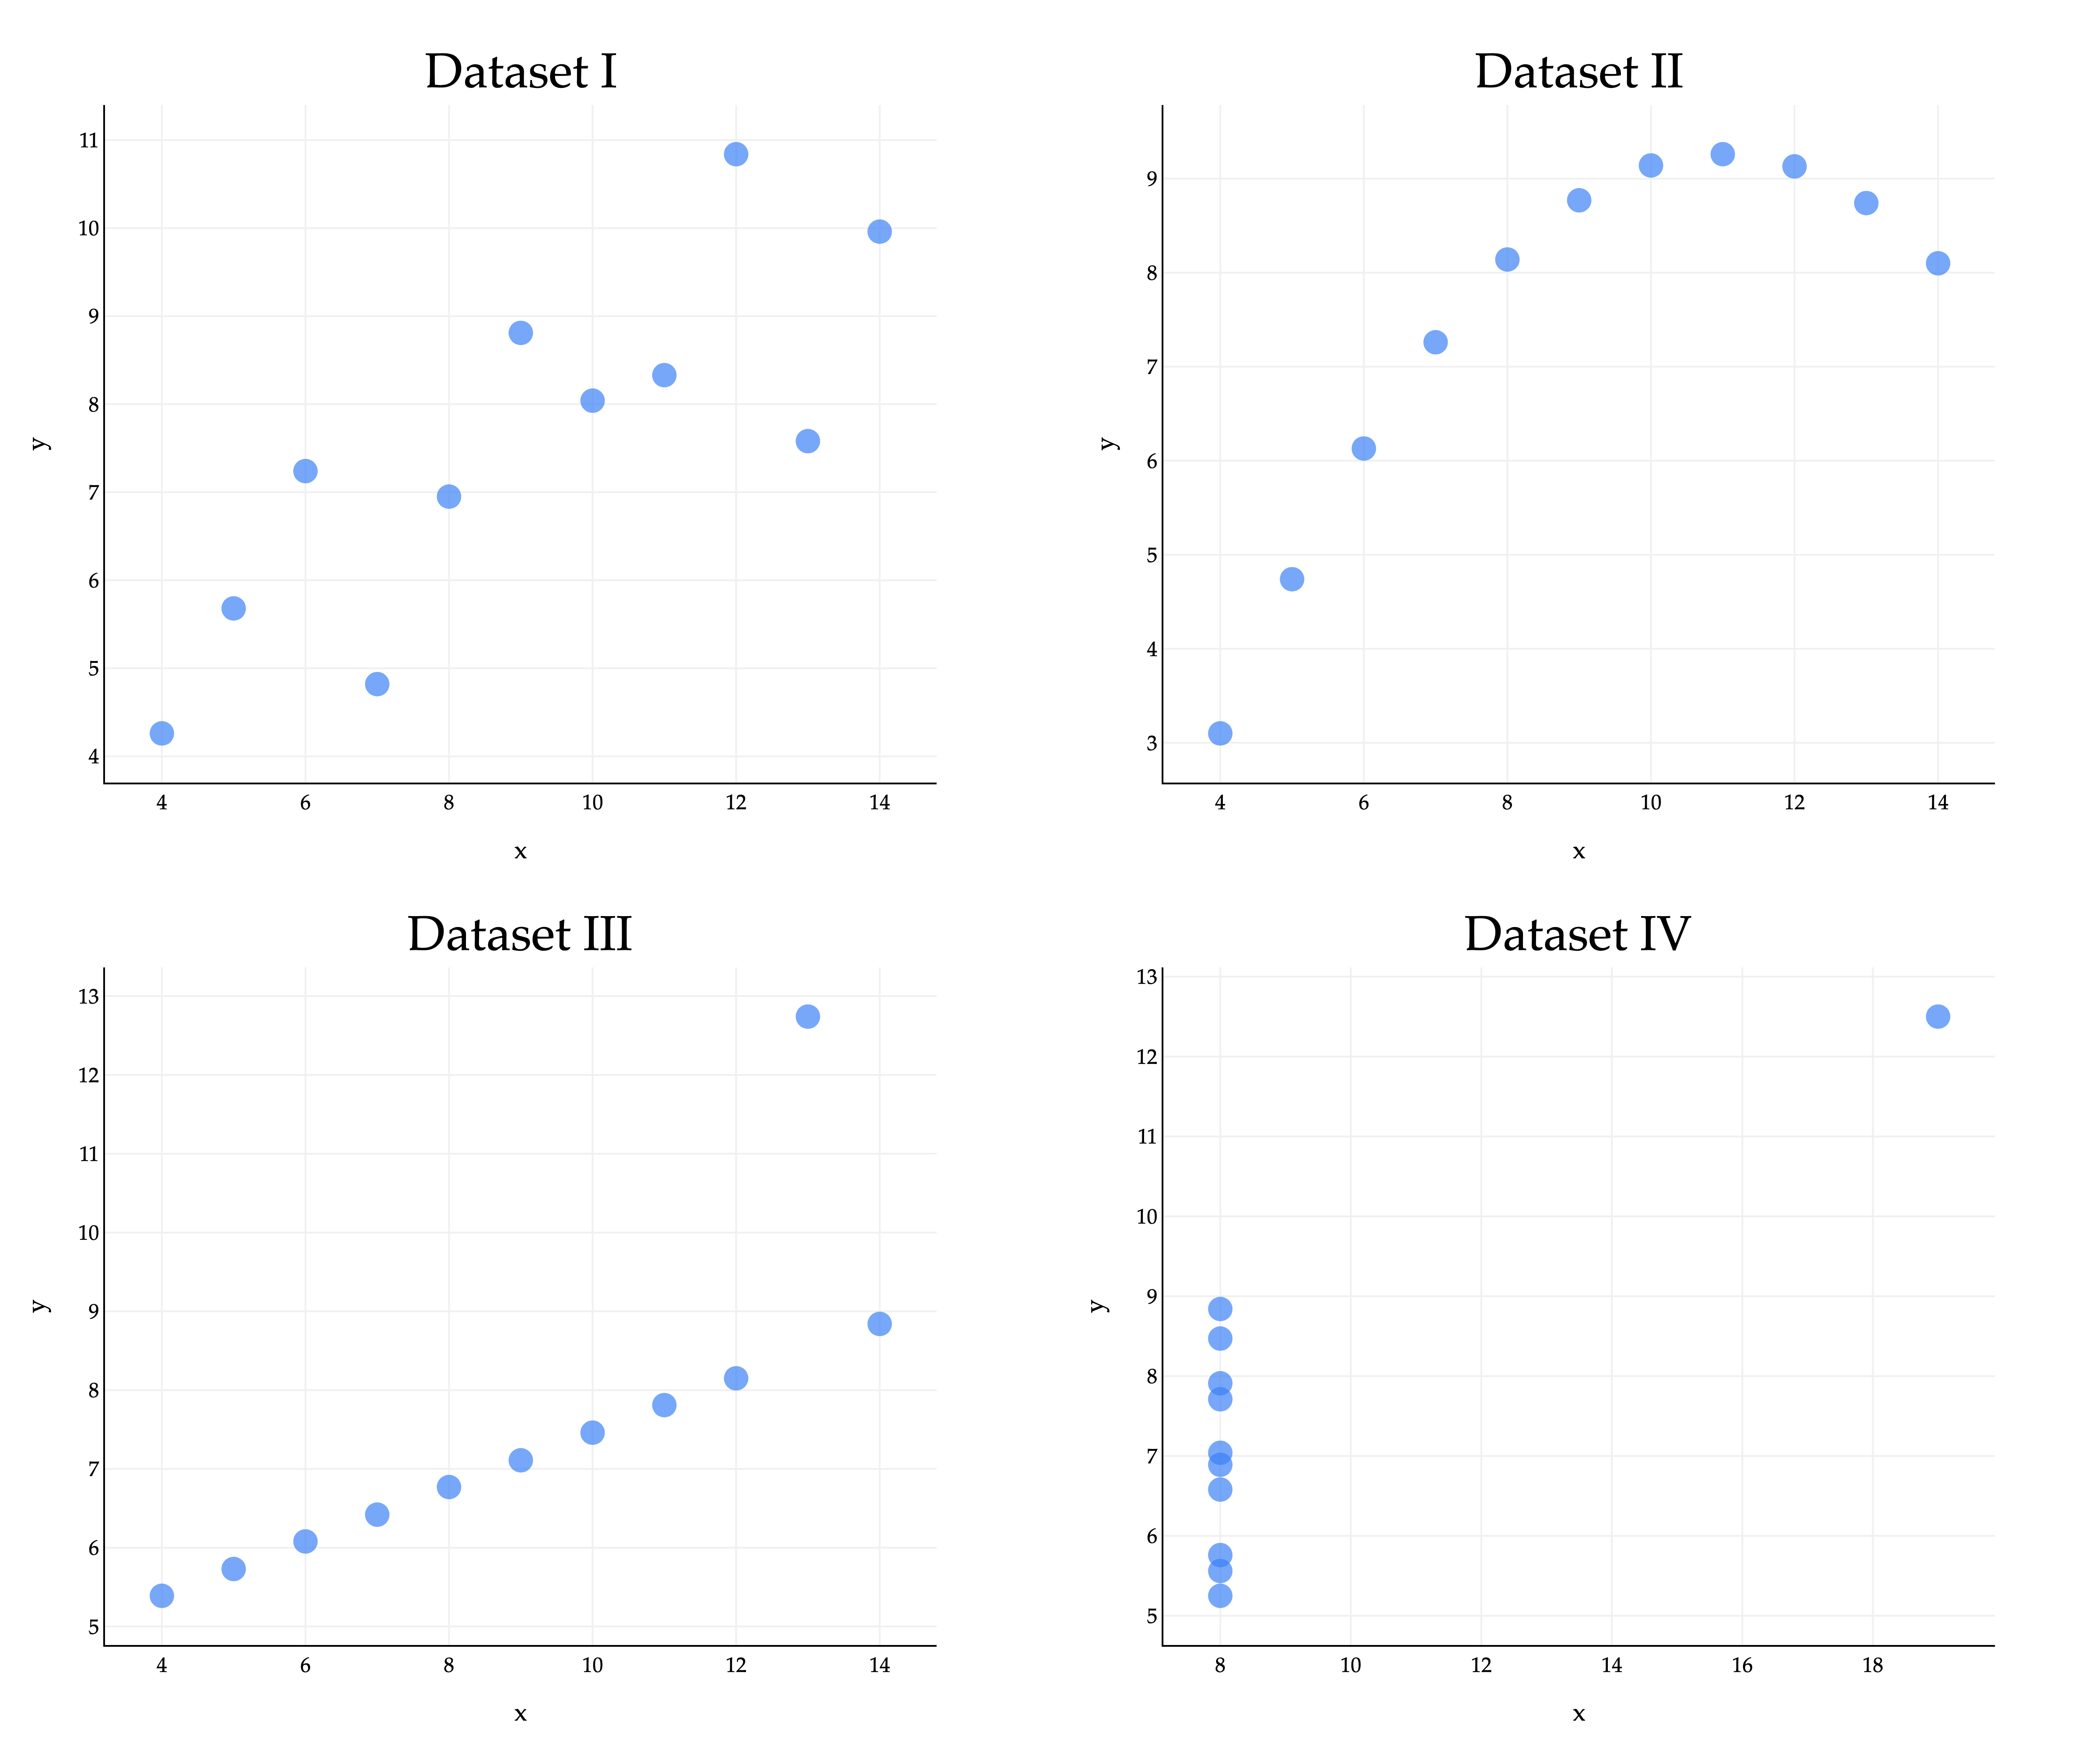

In [ ]:
import numpy as np
import pandas as pd

# Collect results in a list of dicts
summary = []


def correlation(x, y): 
    x_su = (x - np.mean(x)) / np.std(x)
    y_su = (y - np.mean(y)) / np.std(y)
    return np.mean(x_su * y_su)

anscombe = pd.read_csv('data/anscombe.csv')

for n in ['I', 'II', 'III', 'IV']:
    rows = anscombe[anscombe['dataset'] == n]
    x = rows['x']
    y = rows['y']
    r = correlation(x, y)
    
    summary.append({
        "Dataset": n,
        "mean of x": np.round(np.mean(x), 2),
        "mean of y": np.round(np.mean(y), 2),
        "SD of x": np.round(np.std(x), 2),
        "SD of y": np.round(np.std(y), 2),
        "r": np.round(r, 2)
    })

# Convert list of dicts to DataFrame
df_summary = pd.DataFrame(summary).set_index("Dataset")

df_summary

,mean of x,mean of y,SD of x,SD of y,r
Dataset,,,,,
I,9.0,7.5,3.16,1.94,0.82
II,9.0,7.5,3.16,1.94,0.82
III,9.0,7.5,3.16,1.94,0.82
IV,9.0,7.5,3.16,1.94,0.82


In all four datasets:

$$\bar{x} = 9, \bar{y} = 7.5, \sigma_x = 3.16, \sigma_y = 1.94, r = 0.82$$

Because they all share the same five values of these key quantities, they also share the same regression lines, since the optimal slope and intercept are determined just using those five quantities.

$$w_1^* = r \frac{\sigma_y}{\sigma_x} = 0.82 \frac{1.94}{3.16} = 0.52 \qquad w_0^* = \bar{y} - w_1^* \bar{x} = 7.5 - 0.52 \cdot 9 = 2.82$$

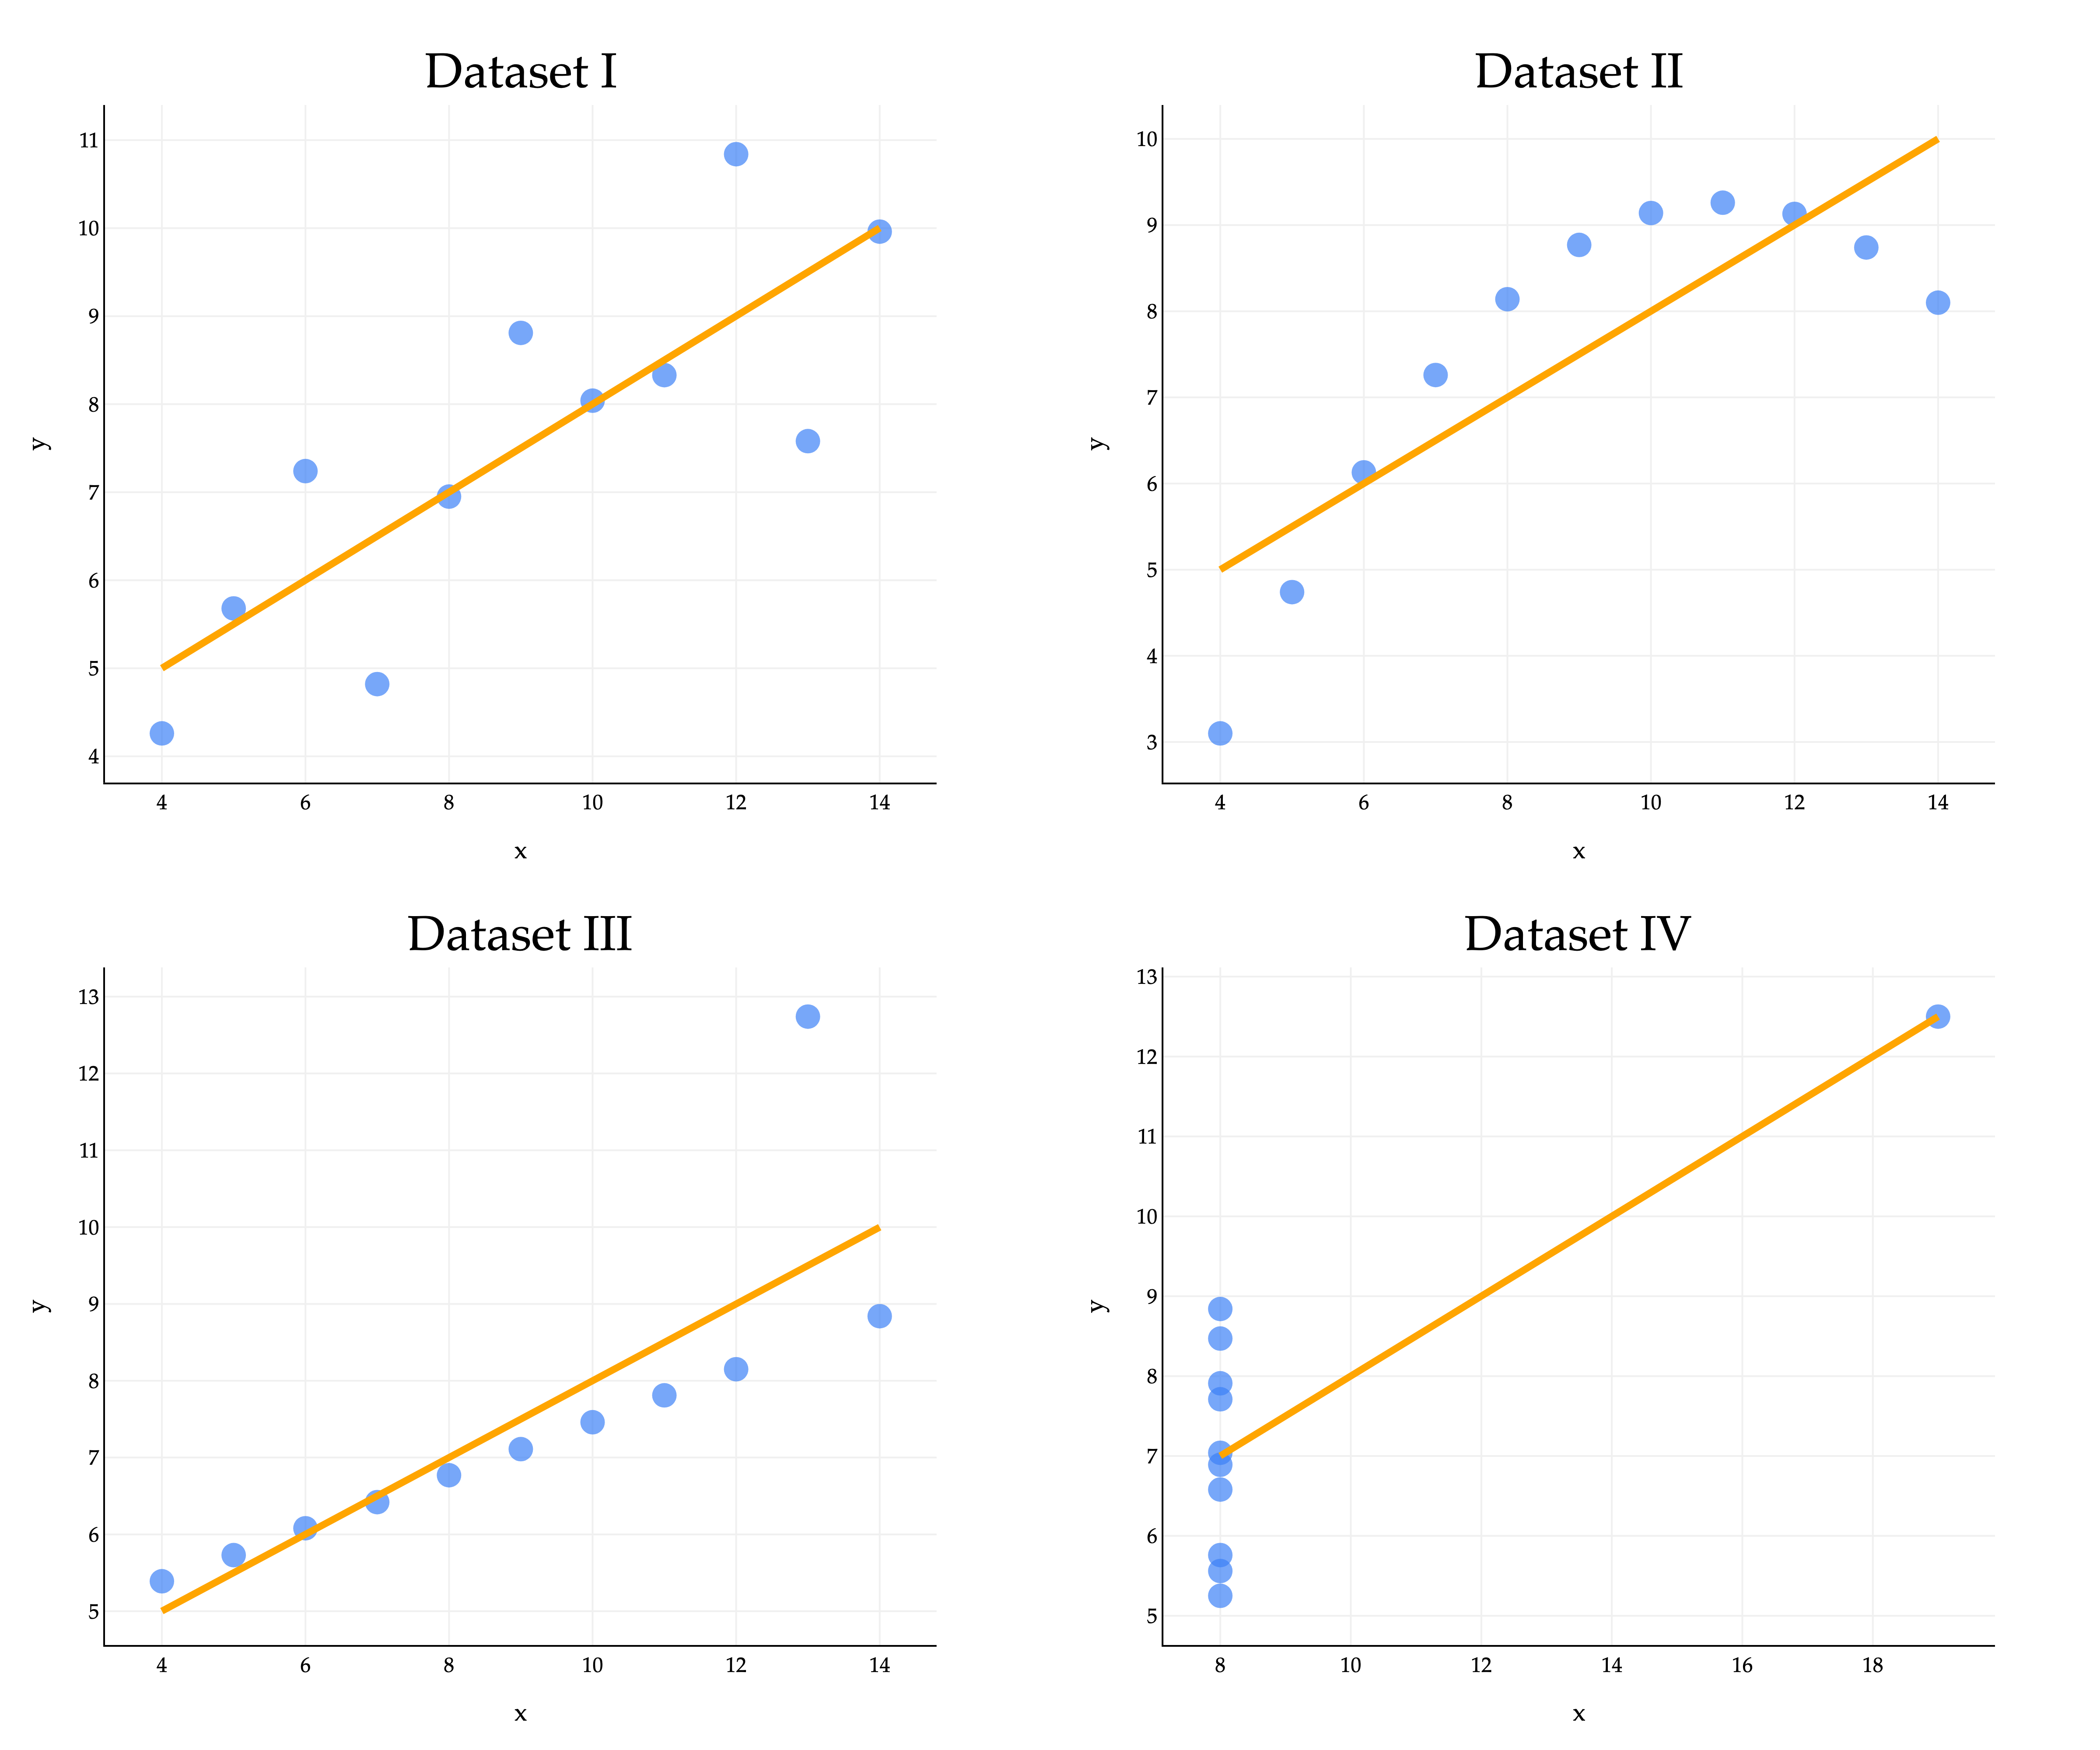

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

anscombe = pd.read_csv('data/anscombe.csv')

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"Dataset {n}" for n in ['I', 'II', 'III', 'IV']],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

for i, n in enumerate(['I', 'II', 'III', 'IV']):
    rows = anscombe[anscombe['dataset'] == n]
    x = rows['x']
    y = rows['y']
    row = i // 2 + 1
    col = i % 2 + 1
    fig.add_trace(
        go.Scatter(
            x=x, y=y,
            mode='markers',
            marker=dict(size=14, color='#3d81f6', opacity=0.7),
            showlegend=False
        ),
        row=row, col=col
    )

fig.update_layout(
    height=1000,
    width=1200,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=60, r=60, t=60, b=60),
    font=dict(
        family="Palatino Linotype, Palatino, serif",
        color="black"
    ),
    annotations=[
        dict(font=dict(size=28, family="Palatino Linotype, Palatino, serif"))
    ]
)

for i in range(1, 5):
    fig.update_xaxes(
        title_text="x",
        row=(i-1)//2+1, 
        col=(i-1)%2+1,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
    )
    fig.update_yaxes(
        title_text="y", 
        row=(i-1)//2+1, 
        col=(i-1)%2+1,
        gridcolor='#f0f0f0',
        showline=True,
        linecolor="black",
        linewidth=1,
    )
for i, n in enumerate(['I', 'II', 'III', 'IV']):
    rows = anscombe[anscombe['dataset'] == n]
    x = rows['x']
    y = rows['y']
    w0_ans = intercept(x, y)
    w1_ans = slope(x, y)
    # Sort x for a proper regression line
    x_sorted = np.sort(x)
    y_pred = w0_ans + w1_ans * x_sorted
    row = i // 2 + 1
    col = i % 2 + 1
    # Add regression line to the corresponding subplot
    fig.add_trace(
        go.Scatter(
            x=x_sorted,
            y=y_pred,
            mode='lines',
            line=dict(color='orange', width=4),
            showlegend=False
        ),
        row=row, col=col
    )


fig.show(renderer="png", scale=4)

The regression line clearly looks better for some datasets than others, with Dataset IV looking particularly off. A high $|r|$ may be evidence of a strong linear association, but it cannot guarantee that a linear model is suitable for a dataset. Moral of the story - **visualize your data before trying to fit a model!** Don't _just_ trust the numbers.